In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
data = [
    ["Data Scientist", "Python, SQL, Machine Learning, Statistics, Data Analysis"],
    ["DevOps Engineer", "AWS, Docker, Kubernetes, Linux, CI/CD"],
    ["Backend Developer", "Java, Python, SQL, REST API"],
    ["Machine Learning Engineer", "Python, TensorFlow, Deep Learning, MLOps"],
    ["Cloud Engineer", "AWS, Azure, Networking, Terraform"],
    ["Full Stack Developer", "HTML, CSS, JavaScript, React, Node.js"],
    ["Cybersecurity Analyst", "Networking, Linux, SIEM, Python"],
    ["AI Engineer", "Python, NLP, Deep Learning, Machine Learning"]
]

df = pd.DataFrame(data, columns=["role", "skills"])
df

,role,skills
0,Data Scientist,"Python, SQL, Machine Learning, Statistics, Dat..."
1,DevOps Engineer,"AWS, Docker, Kubernetes, Linux, CI/CD"
2,Backend Developer,"Java, Python, SQL, REST API"
3,Machine Learning Engineer,"Python, TensorFlow, Deep Learning, MLOps"
4,Cloud Engineer,"AWS, Azure, Networking, Terraform"
5,Full Stack Developer,"HTML, CSS, JavaScript, React, Node.js"
6,Cybersecurity Analyst,"Networking, Linux, SIEM, Python"
7,AI Engineer,"Python, NLP, Deep Learning, Machine Learning"


In [3]:
df.to_csv("raw_skills.csv", index=False)

In [4]:
df = pd.read_csv("raw_skills.csv")
df

,role,skills
0,Data Scientist,"Python, SQL, Machine Learning, Statistics, Dat..."
1,DevOps Engineer,"AWS, Docker, Kubernetes, Linux, CI/CD"
2,Backend Developer,"Java, Python, SQL, REST API"
3,Machine Learning Engineer,"Python, TensorFlow, Deep Learning, MLOps"
4,Cloud Engineer,"AWS, Azure, Networking, Terraform"
5,Full Stack Developer,"HTML, CSS, JavaScript, React, Node.js"
6,Cybersecurity Analyst,"Networking, Linux, SIEM, Python"
7,AI Engineer,"Python, NLP, Deep Learning, Machine Learning"


In [5]:
def recommend_roles(user_input, dataframe, top_n=3):
    user_skills = [skill.strip() for skill in user_input.split(",") if skill.strip()]
    
    if len(user_skills) < 3:
        return "Please enter at least 3 skills."
    
    user_text = ", ".join(user_skills)
    
    corpus = dataframe["skills"].astype(str).tolist() + [user_text]
    
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(corpus)
    
    user_vector = tfidf_matrix[-1]
    role_vectors = tfidf_matrix[:-1]
    
    similarity_scores = cosine_similarity(user_vector, role_vectors).flatten()
    
    result = dataframe.copy()
    result["similarity_score"] = similarity_scores
    result["match_percentage"] = result["similarity_score"] * 100
    result = result.sort_values("similarity_score", ascending=False)
    
    top_results = result.head(top_n)[["role", "skills", "match_percentage"]]
    return top_results

In [6]:
user_input = "Python, SQL, Machine Learning"
recommend_roles(user_input, df, top_n=3)

,role,skills,match_percentage
0,Data Scientist,"Python, SQL, Machine Learning, Statistics, Dat...",60.914543
7,AI Engineer,"Python, NLP, Deep Learning, Machine Learning",60.526945
2,Backend Developer,"Java, Python, SQL, REST API",31.178627


In [7]:
results = recommend_roles("Python, SQL, Machine Learning", df, top_n=3)

if isinstance(results, str):
    print(results)
else:
    for i, row in results.iterrows():
        print(f"{row['role']} - {row['match_percentage']:.2f}%")

Data Scientist - 60.91%
AI Engineer - 60.53%
Backend Developer - 31.18%


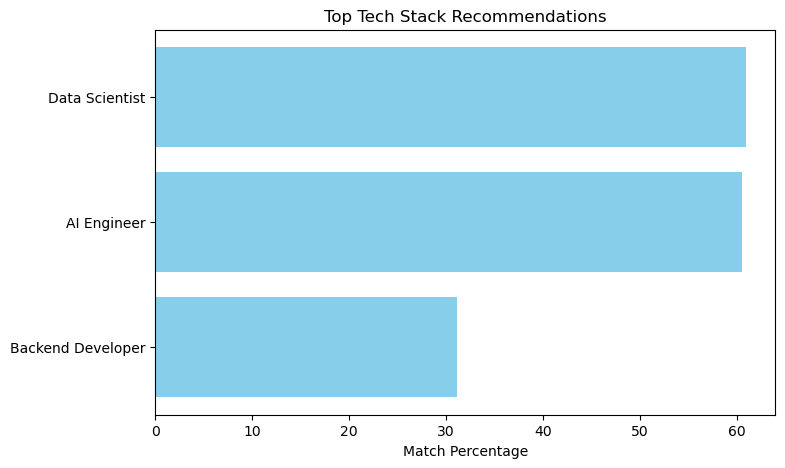

In [8]:
import matplotlib.pyplot as plt

results = recommend_roles("Python, SQL, Machine Learning", df, top_n=3)

plt.figure(figsize=(8, 5))
plt.barh(results["role"], results["match_percentage"], color="skyblue")
plt.xlabel("Match Percentage")
plt.title("Top Tech Stack Recommendations")
plt.gca().invert_yaxis()
plt.show()